### Data loading

In [1]:
import pandas as pd
chronos = pd.read_csv("../data/CRISPR_gene_effect.csv",index_col=0).dropna()
chronos.columns = [g.split()[0] for g in chronos.columns]

### Histgrams (Fig. S1a)

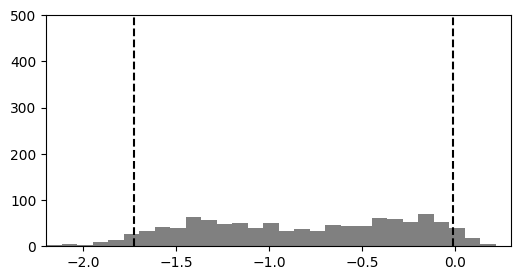

In [2]:
# Figure S1a
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,3))
bins = np.linspace(-2.2,0.3, 31)
gene="CCND1"
plt.hist(chronos[gene], bins=bins, color="gray")
plt.xlim(-2.2, 0.3)
plt.ylim(0, 500)

lower_5th = np.percentile(chronos[gene], 5)
upper_95th = np.percentile(chronos[gene], 95)
plt.axvline(lower_5th, color="black", linestyle="--")
plt.axvline(upper_95th, color="black", linestyle="--")
plt.show()

### Selectivity (Figs. S1b-e)

In [3]:
#Shimada et al., 2021 https://elifesciences.org/articles/57116
#Calculating Selectivity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from tqdm import tqdm
np.random.seed(42)
percentile = 5
rank = 100

X1 = percentile / 100
X2 = 1 - X1

D_G_X005,E_G_X005,E_G_X050,E_G_X095 = {},{},{},{}

# Calculate the 5th and 95th percentiles for each gene
for x in tqdm(chronos.columns):
    sorted_values = sorted(chronos[x])
    E_G_X005[x] = sorted_values[max(0, int(X1 * len(chronos.index)) - 1)]
    E_G_X095[x] = sorted_values[max(0, int(X2 * len(chronos.index)) - 1)]
    E_G_X050[x] = np.median(sorted_values)
    D_G_X005[x] = E_G_X005[x] - E_G_X095[x]

# Convert values to lists for spline fitting
X = np.array(list(E_G_X005.values()))
Y = np.array(list(E_G_X095.values()))

#Spline
# Sort X and Y based on X for spline fitting
sorted_indices = np.argsort(X)
X_sorted = X[sorted_indices]
Y_sorted = Y[sorted_indices]

# Use UnivariateSpline for a smoother fit
spline = UnivariateSpline(X_sorted, Y_sorted)
spline.set_smoothing_factor(100)  # Adjust this smoothing factor as needed

# Calculate Selectivity with the smoothed spline
sel = pd.DataFrame(index=["selectivity"], columns=chronos.columns)
for x in tqdm(sel.columns):
    sel[x] = (E_G_X095[x] - spline(E_G_X005[x])) / (spline(E_G_X005[x]) - E_G_X005[x])
selT = sel.T
selT['E005'] =  E_G_X005.values()

100%|██████████| 17386/17386 [00:07<00:00, 2276.71it/s]


linear   CV RMSE = 0.09882 ± 0.00418
s=50     CV RMSE = 0.08857 ± 0.00991
s=100    CV RMSE = 0.06916 ± 0.00196
s=150    CV RMSE = 0.06916 ± 0.00196


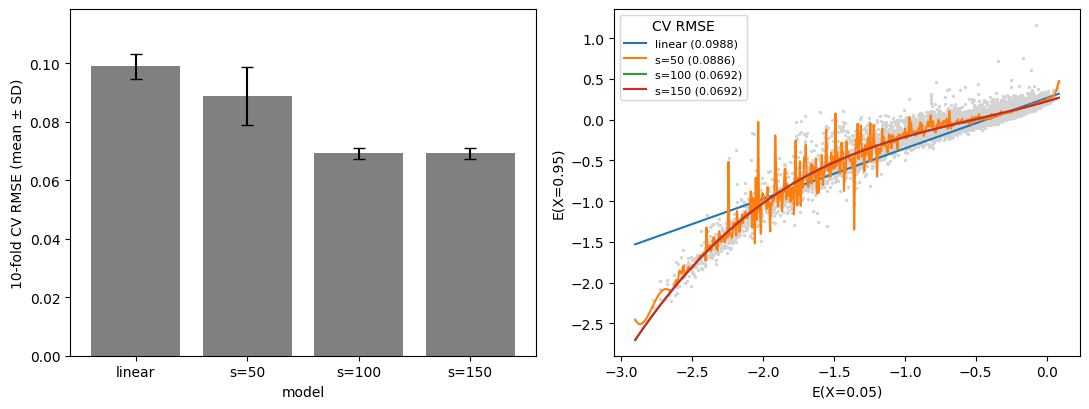

In [4]:
import numpy as np, matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from scipy.stats import linregress, wilcoxon
from sklearn.model_selection import KFold

X = np.array(list(E_G_X005.values()))
Y = np.array(list(E_G_X095.values()))

o = np.argsort(X)
Xs, Ys = X[o], Y[o]
Xu, inv = np.unique(Xs, return_inverse=True)
Yu = np.bincount(inv, weights=Ys) / np.bincount(inv)
n = len(Xu)

settings = [("linear", None), ("s=50", 50), ("s=100", 100),("s=150", 150)]

kf = KFold(n_splits=10, shuffle=True, random_state=42) 
folds = [(np.sort(tr), np.sort(te)) for tr, te in kf.split(Xu)]

res = {}
for name, s in settings:
    errs = []
    for tr, te in folds:
        if s is None:
            r = linregress(Xu[tr], Yu[tr])
            pred = r.slope * Xu[te] + r.intercept
        else:
            sp = UnivariateSpline(Xu[tr], Yu[tr], s=s * len(tr) / n)
            pred = sp(Xu[te])
        errs.append(np.sqrt(((pred - Yu[te]) ** 2).mean()))  
    res[name] = np.array(errs)

for name, e in res.items():
    print(f"{name:8s} CV RMSE = {e.mean():.5f} ± {e.std(ddof=1):.5f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

names = list(res)
means = [res[k].mean() for k in names]
sds = [res[k].std(ddof=1) for k in names]
ax[0].bar(names, means, yerr=sds, capsize=4, color="grey")
ax[0].set_ylabel("10-fold CV RMSE (mean ± SD)")
ax[0].set_xlabel("model")
ax[0].set_ylim(0, max(np.array(means) + np.array(sds)) * 1.15)

ax[1].scatter(Xu, Yu, s=2, c="lightgrey", rasterized=True)
xg = np.linspace(Xu.min(), Xu.max(), 500)
for name, s in settings:
    if s is None:
        r = linregress(Xu, Yu)
        yg = r.slope * xg + r.intercept
    else:
        yg = UnivariateSpline(Xu, Yu, s=s)(xg)
    ax[1].plot(xg, yg, lw=1.5, label=f"{name} ({res[name].mean():.4f})")
ax[1].set_xlabel("E(X=0.05)")
ax[1].set_ylabel("E(X=0.95)")
ax[1].legend(fontsize=8, title="CV RMSE")

plt.savefig('../result/figure.svg')
plt.tight_layout()
plt.show()

In [7]:
for k, v in rmse.items():
    print(v)

0.09890029086475632
0.08906857738155077
0.06918180935621045
0.06918180935621045


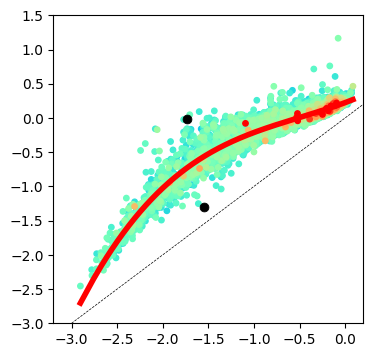

In [8]:
# Fig. S1b
plt.figure(figsize=(4, 4))
plt.scatter(X, Y, s=15,cmap="rainbow",vmax=1, c=selT["selectivity"])

genels = ["CCND1", "H2AC15"]
for g in genels:
    plt.scatter(E_G_X005[g], E_G_X095[g], color="black", s=40, ec="black", linewidth=0.6)
plt.plot(X_sorted, spline(X_sorted), color='red', lw=4)
plt.axline((0, 0), (0.1, 0.1), color="black", lw=0.5, ls="--")
plt.xlim((-3.2,0.2))
plt.ylim((-3,1.5))
plt.show()

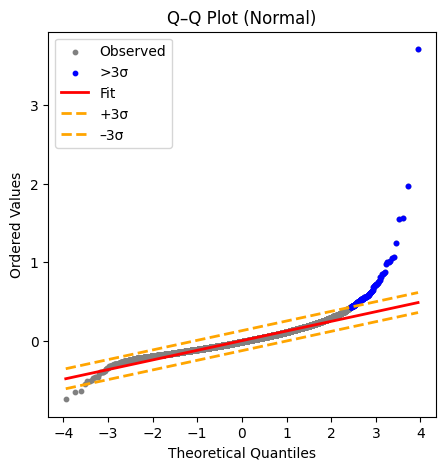

In [9]:
#Figure S1c
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Generate Q-Q data and regression info
(osm, osr), (slope, intercept, r) = stats.probplot(selT.selectivity, dist="norm")

# Predicted (fitted) values
fitted = slope * osm + intercept

# Residuals
residuals = osr - fitted

# Compute standard deviation of residuals
sigma = np.std(residuals)

# Plot QQ + residuals
fig, axes = plt.subplots(1, 1, figsize=(5, 5))

# === Q–Q plot ===
axes.scatter(osm, osr, s=10, color='gray', label="Observed")

axes.scatter(osm[-129:],  # highlight >3σ points
                osr[-129:],
                s=10, color='blue', label='>3σ')
        

axes.plot(osm, fitted, color='red', lw=2, label="Fit")

# Add ±3σ lines (vertical shift from fitted line)
axes.plot(osm, fitted + 3 * sigma, color='orange', ls = '--',lw=2, label='+3σ')
axes.plot(osm, fitted - 3 * sigma, color='orange', ls = '--', lw=2, label='–3σ')

axes.set_title("Q–Q Plot (Normal)")
axes.set_xlabel("Theoretical Quantiles")
axes.set_ylabel("Ordered Values")
axes.legend()


plt.show()


c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


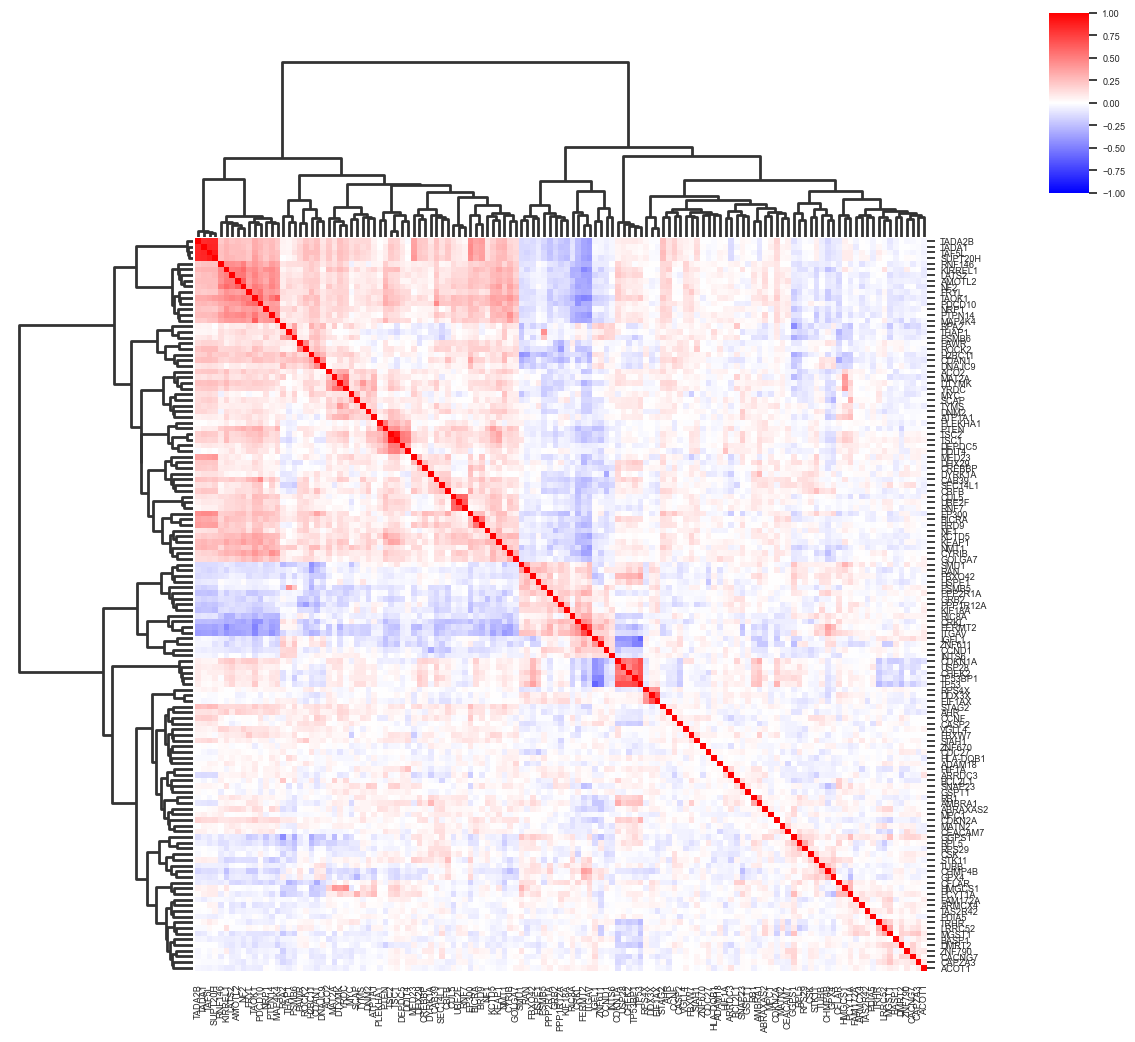

In [10]:
#Fig. S1d
import seaborn as sns
selT = sel.T.copy()
selT = selT.sort_values('selectivity')
selT['fitted'] = fitted
selT['sigma'] = residuals/sigma
genes = selT[selT.sigma>3].index
corr = chronos[genes].corr()
sns.set(font_scale= 0.6)
g = sns.clustermap(corr, cmap="bwr",vmax=1,vmin=-1, method = "ward",
               cbar_pos=(1.05, 0.85, 0.04, 0.18),
               tree_kws=dict(linewidths=2),figsize=(10,10),
               yticklabels=genes, xticklabels=genes)

plt.show()

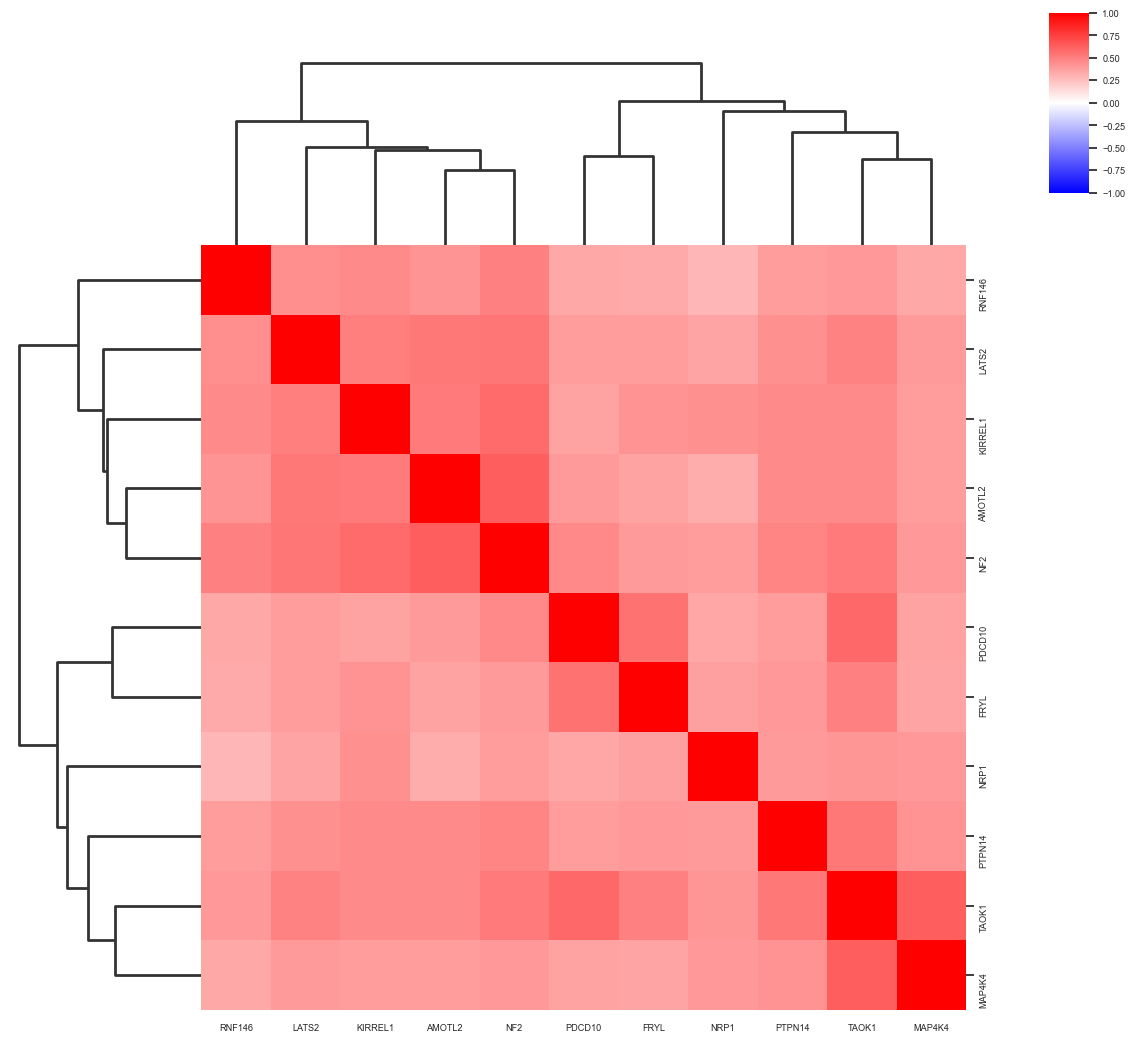

In [ ]:
#Fig. S1e
import seaborn as sns
#genes = ['TSC1','TSC2','PTEN','PLEKHA1','DDIT4', 'DEPDC5']
#genes = ['TADA2B', 'TADA1', 'SUPT20H', 'TAF5L']
#genes = ['CDKN1A', 'USP28', 'CHEK2', 'TP53']
genes = ['AMOTL2', 'KIRREL1', 'NF2', 'PDCD10', 'RNF146', 'TAOK1', 'PTPN14', 'MAP4K4', 'FRYL', 'LATS2', 'NRP1']
corr = chronos[genes].corr()
g = sns.clustermap(corr, cmap="bwr",vmax=1,vmin=-1, method = "ward",
               cbar_pos=(1.05, 0.85, 0.04, 0.18),
               tree_kws=dict(linewidths=2),figsize=(10,10),
               yticklabels=genes, xticklabels=genes)
plt.savefig('../result/Selectivity_clustermap129.svg')
plt.show()

# Sensitivity cutoff

In [6]:
for cutoff in [2,2.5,3,3.5,4]:
    genes = selT[selT.sigma>cutoff].index
    print(len(genes))

AttributeError: 'DataFrame' object has no attribute 'sigma'

In [21]:
for cutoff in [2,2.5,3,3.5,4]:
    genes = selT[selT.sigma>cutoff].index
    corr = chronos[genes].corr()
    corr.to_csv(f'../data/cutoffs/{cutoff}_corr.csv')

c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


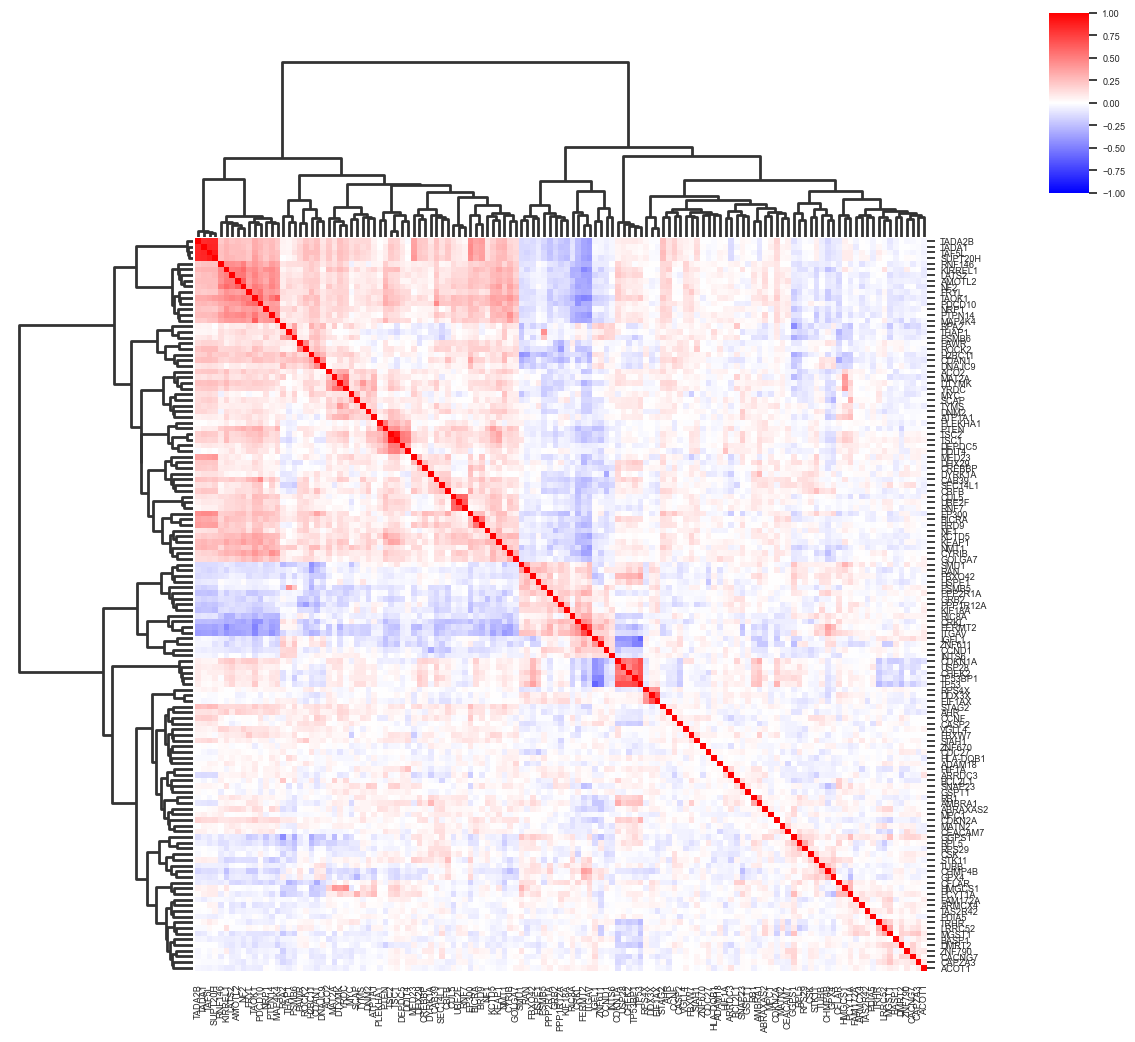

In [11]:
cutoff = 3
genes = selT[selT.sigma>cutoff].index
corr = chronos[genes].corr()
sns.set(font_scale= 0.6)
g = sns.clustermap(corr, cmap="bwr",vmax=1,vmin=-1, method = "ward",
               cbar_pos=(1.05, 0.85, 0.04, 0.18),
               tree_kws=dict(linewidths=2),figsize=(10,10),
               yticklabels=genes, xticklabels=genes)

plt.show()

c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\ki949\OneDrive - Mass General Brigham\Desktop\Kitagawa Lab\論文\Hagiwara\statemap\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


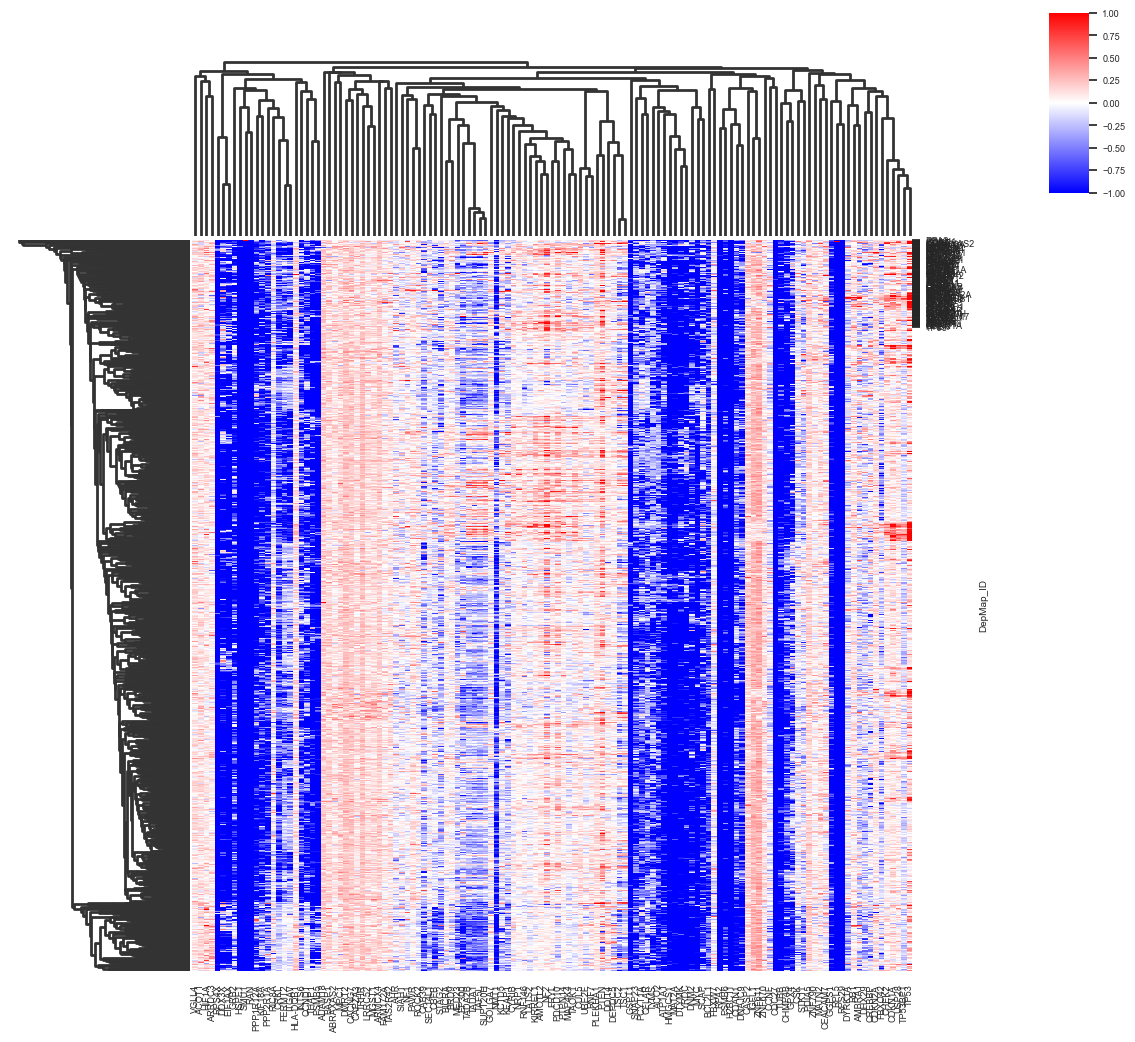

In [ ]:
cutoff = 3
genes = selT[selT.sigma>cutoff].index
corr = chronos[genes]
sns.set(font_scale= 0.6)
g = sns.clustermap(corr, cmap="bwr",vmax=1,vmin=-1, method = "ward",
               cbar_pos=(1.05, 0.85, 0.04, 0.18),
               tree_kws=dict(linewidths=2),figsize=(10,10),
               yticklabels=genes, xticklabels=genes)

plt.show()

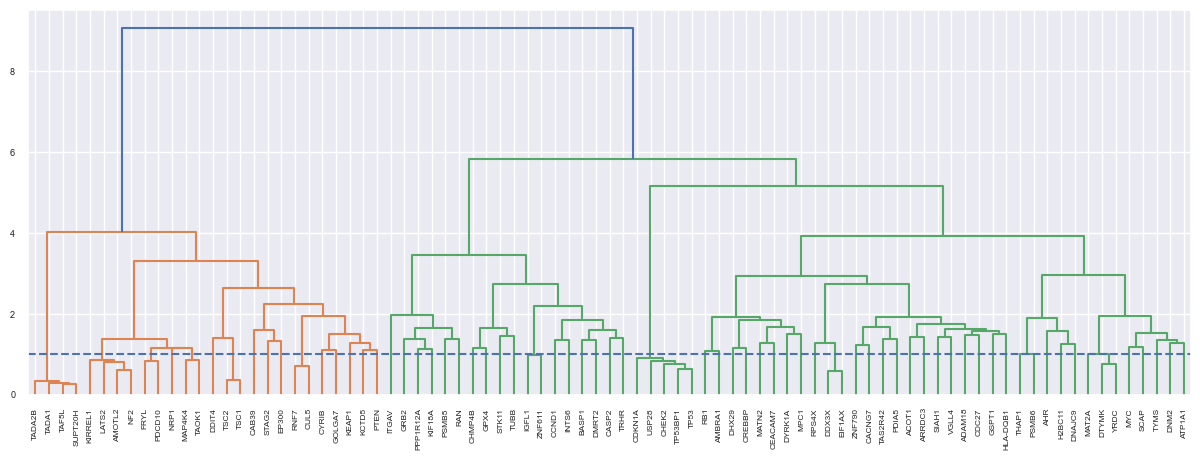

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
cutoff = 4
genes = selT[selT.sigma>cutoff].index
corr = chronos[genes].corr()

Z = linkage(corr, method="ward")

plt.figure(figsize=(15,5))
dendrogram(Z, labels=genes)
plt.axhline(1, ls="--")
plt.show()

cluster = fcluster(Z, t=2, criterion="distance")

In [75]:
members = {}
for c,g in zip(cluster,genes):
    if c not in members:
        members[c] = []
    members[c].append(g)
    if g == 'NF2':
        nf2_c = c
for m in sorted(members[nf2_c]):
    print(m)

AMOTL2
ARHGAP35
FRYL
KIRREL1
LATS2
MAP4K4
NF2
NRP1
PDCD10
PTPN14
RAP2B
RNF146
TAOK1


In [56]:
for m in sorted(members[7]):
    print(m)

AMOTL2
CYRIB
KIRREL1
LATS2
MAP4K4
NF2
NRP1
PTPN14
RNF146
TAOK1


In [55]:
members

{np.int32(15): ['RPA2', 'BCL2L1', 'PSMB6'],
 np.int32(1): ['CDAN1', 'H2BC11', 'DNAJC9'],
 np.int32(17): ['CCNF', 'ZNF670', 'CDC27'],
 np.int32(4): ['ACO2', 'NMT1', 'STAG2', 'AHR'],
 np.int32(25): ['ABRAXAS2', 'MPC1'],
 np.int32(11): ['CRKL', 'FERMT2', 'RIC8A', 'ITGAV'],
 np.int32(24): ['FAM172A', 'TAS2R42'],
 np.int32(34): ['HMGCS1', 'MAT2A', 'TYMS', 'DTYMK', 'YRDC'],
 np.int32(27): ['MED23', 'DHX29', 'CREBBP'],
 np.int32(23): ['LRRC52', 'MGST1', 'TRHR'],
 np.int32(5): ['BICRA', 'BRD9', 'TAF5L', 'TADA2B', 'TADA1', 'SUPT20H'],
 np.int32(22): ['ARMCX4', 'GSPT1', 'ADAM18'],
 np.int32(26): ['CAPZA3', 'GGPS1', 'ZNF790', 'DMRT2', 'CACNG7'],
 np.int32(20): ['HIF1A', 'ARRDC3'],
 np.int32(33): ['PLEKHA1', 'DEPDC5', 'DDIT4', 'TSC2', 'TSC1', 'PTEN'],
 np.int32(8): ['NF1', 'GOLGA7', 'FRYL', 'CAB39', 'KCTD5', 'KEAP1', 'PDCD10'],
 np.int32(30): ['RPL5', 'RPS29'],
 np.int32(19): ['CDKN2A', 'HLA-DQB1'],
 np.int32(36): ['PCYT1A', 'CFLAR', 'PDIA5'],
 np.int32(28): ['CSK', 'SEC14L1', 'CBFB', 'STK11', 'EP